# NHL Cap Hit: exploratory analysis

A look at NHL skater pay across `23/24`, `24/25`, and `25/26`, before the prediction model.

The sample is skaters with at least 10 games. Pay is share of that season's salary cap. Most market charts exclude entry-level deals. Prefer the median. Forwards = centers + wingers.

**Story order:** first the signing-age view (when deals start), then who filled NHL rosters over these three seasons and how they were paid.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns

from viz_labels import *

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
PCT0 = FuncFormatter(lambda v, _: f"{v:.0%}")
PCT1 = FuncFormatter(lambda v, _: f"{v:.1%}")


def label_n(ax, bars, ns, dy=None, fs=8):
    for b, n in zip(bars, ns):
        h = b.get_height()
        gap = dy if dy is not None else max(abs(h) * 0.03, 0.8)
        ax.text(b.get_x() + b.get_width() / 2, h + gap, f"n={int(n)}", ha="center", va="bottom", fontsize=fs)


def plot_length_mix(ax, data, min_n=15, palette=None, xtick_fs=8, labeled=True):
    """Stacked share of contract-length groups by age (needs Age, ContractLength)."""
    palette = LENGTH_COLORS if palette is None else palette
    mix = data.assign(LG=data.ContractLength.map(length_group))
    age_n = mix.groupby("Age").size()
    keep = age_n[age_n >= min_n].index.sort_values()
    ct = (
        pd.crosstab(mix.Age, mix.LG, normalize="index")
        .reindex(index=keep, columns=LENGTH_GROUP_ORDER)
        .fillna(0)
    )
    x, bottom = np.arange(len(keep)), np.zeros(len(keep))
    for g, c in zip(LENGTH_GROUP_ORDER, palette):
        kw = {"color": c, "edgecolor": "white", "width": 0.85}
        if labeled:
            kw["label"] = f"{g} years"
        ax.bar(x, ct[g], bottom=bottom, **kw)
        bottom += ct[g].to_numpy()
    ax.set_xticks(x, [f"{a}\nn={age_n[a]}" for a in keep], fontsize=xtick_fs)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(PCT0)
    return age_n


ROOT = Path.cwd()
DATA = ROOT / "NHL Skater Cap Hit.csv"
DATA


In [3]:
df = pd.read_csv(DATA)
df["FD"] = np.where(df.Pos_group.eq("D"), "D", "F")
df["Is_ELC"] = df.Is_ELC.astype(int)
df["season_end_year"] = 2000 + df.Season.str.split("-").str[1].astype(int)
df["ExpiryYear_approx"] = df.season_end_year + df.YearsRemaining
df["Age_at_signing_approx"] = df.Age - ((df.ContractLength - 1) - df.YearsRemaining)

non_elc = df[df.Is_ELC == 0].copy()
elc = df[df.Is_ELC == 1].copy()
deal_keys = ["playerId", "CapHit", "ContractLength", "ExpiryYear_approx"]
deals_non_elc = non_elc.sort_values(["playerId", "Season"]).drop_duplicates(deal_keys)

print(f"Rows: {len(df)}")
print(df.Season.value_counts().sort_index().to_string())
print(f"ELC / non-ELC: {(df.Is_ELC==1).sum()} / {(df.Is_ELC==0).sum()}")
print(f"F / D: {(df.FD=='F').sum()} / {(df.FD=='D').sum()}")
print(f"Unique non-ELC deals: {len(deals_non_elc)} (from {len(non_elc)} season records)")
df.head()


Rows: 2310
Season
23-24    771
24-25    761
25-26    778
ELC / non-ELC: 335 / 1975
F / D: 1511 / 799
Unique non-ELC deals: 1302 (from 1975 season records)


## 1. Contract length and age when the deal started (not entry-level)


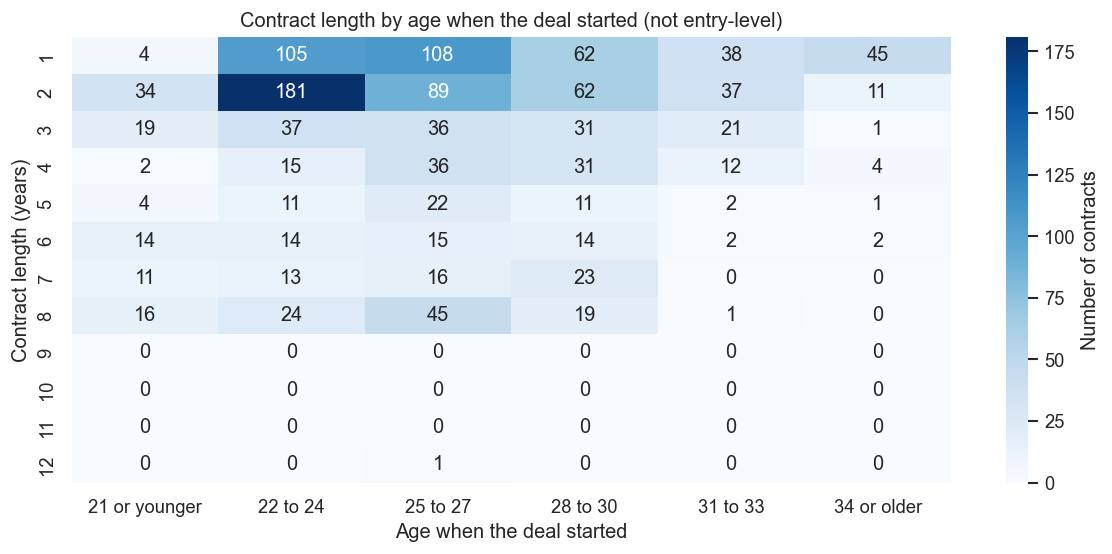

In [15]:
bins = [17, 22, 25, 28, 31, 34, 45]
labels = ["21 or younger", "22 to 24", "25 to 27", "28 to 30", "31 to 33", "34 or older"]
tmp = deals_non_elc.assign(AgeBin=pd.cut(deals_non_elc.Age_at_signing_approx, bins=bins, labels=labels, right=True))
heat = pd.crosstab(tmp.ContractLength, tmp.AgeBin).reindex(index=range(1, 13), columns=labels).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt="d", cmap=CMAP_LENGTH, ax=ax, cbar_kws={"label": "Number of contracts"})
ax.set(xlabel=lab("Age_at_signing_approx"), ylabel=lab("ContractLength"),
       title="Contract length by age when the deal started (not entry-level)")
plt.tight_layout(); plt.subplots_adjust(bottom=0.18); plt.show()


### Takeaways

Across the non entry-level contracts collected here, the early and mid 20s are dominated by one and two year deals, the bridge and prove-it terms that follow an entry-level contract while a player's role and restricted free agent value are still being settled. Longer commitments behave differently, clustering at signing ages below about 30 and nearly disappearing once a player reaches 34, which reads as clubs preferring to buy term while the risk of late-career decline is still low.

That signing window matters for everything that follows, because when the later charts show an older player carrying a long contract, the deal itself usually started years earlier.


## 2. How many players by cap hit size

Bins in millions of dollars. From here on, charts describe who was in the league over the last three seasons, not when contracts were signed.


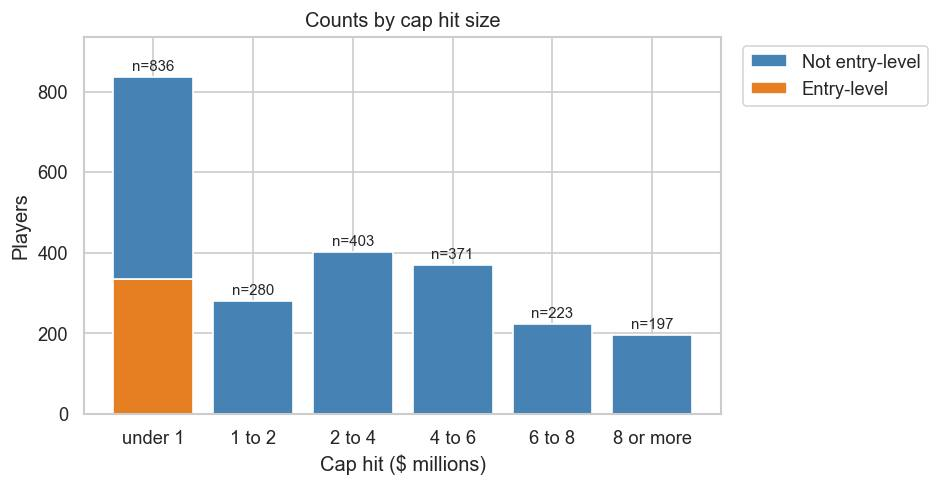

In [5]:
bins, labels = [0, 1, 2, 4, 6, 8, 20], ["under 1", "1 to 2", "2 to 4", "4 to 6", "6 to 8", "8 or more"]
tmp = df.assign(CapBin=pd.cut(df["CapHit"], bins=bins, labels=labels, right=False))
stack = (
    pd.crosstab(tmp.CapBin, tmp.Is_ELC)
    .reindex(index=labels, columns=[0, 1])
    .fillna(0)
    .astype(int)
)
stack.columns = ["Not entry-level", "Entry-level"]
totals = stack.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(labels))
b_elc = ax.bar(x, stack["Entry-level"], color=COLOR_ELC, edgecolor="white", label="Entry-level")
b_non = ax.bar(
    x, stack["Not entry-level"], bottom=stack["Entry-level"],
    color=COLOR_NON_ELC, edgecolor="white", label="Not entry-level",
)
for xi, tot in zip(x, totals.values):
    ax.text(xi, tot + 8, f"n={int(tot)}", ha="center", va="bottom", fontsize=9)
ax.set(
    xticks=x, xticklabels=labels, xlabel=lab("CapHit"), ylabel="Players",
    title="Counts by cap hit size", ylim=(0, totals.max() * 1.12),
)
ax.legend(handles=[b_non, b_elc], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


### Takeaways

Turning from when deals were signed to who actually filled NHL rosters, the last three seasons put the largest group of skaters under 1M, a band where entry-level and cheap non entry-level contracts sit side by side, with non entry-level slightly more numerous in this sample. The everyday market sits closer to 2M to 6M, where post entry-level raises, bridge follow-ups and a wide mix of lineup roles all overlap.

The 1 to 2M, 6 to 8M and 8M+ bins hold similar counts in this sample, although one reading is that the cheaper band turns over more players while the top band repeats the same high-responsibility core from season to season.


## 3. Contract length: how common, how paid, how used (not entry-level)

Among non entry-level skaters in these three years: how often each length appears, how median cap share moves with length, and how games played look.


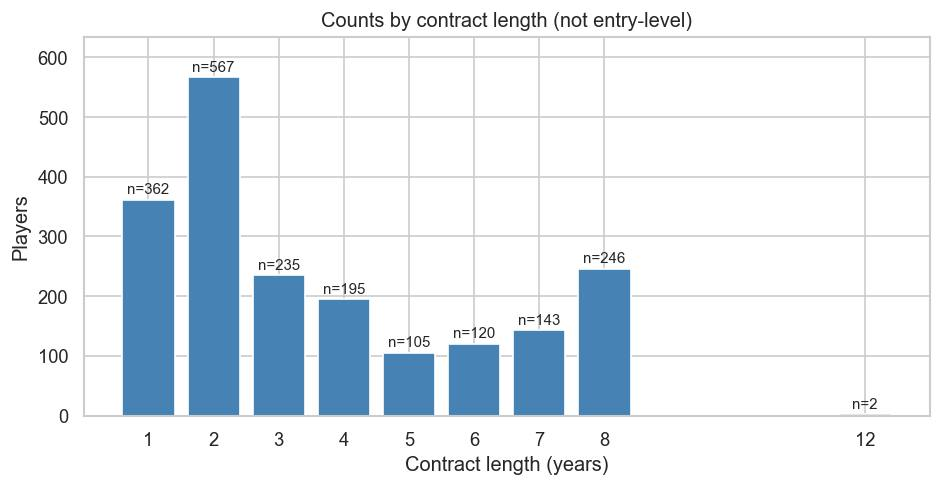

In [7]:
counts = non_elc["ContractLength"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(counts.index.astype(int), counts.values, color=COLOR_MARKET, edgecolor="white")
label_n(ax, bars, counts.values, dy=5, fs=9)
ax.set(xlabel=lab("ContractLength"), ylabel="Players",
       title="Counts by contract length (not entry-level)",
       xticks=counts.index.astype(int), ylim=(0, counts.max() * 1.12))
plt.tight_layout(); plt.show()


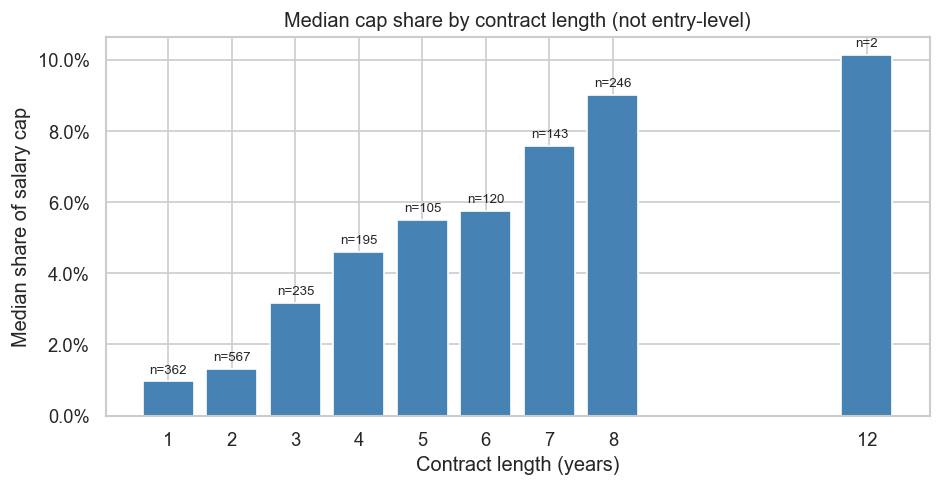

In [9]:
by_len = (
    non_elc.groupby("ContractLength", as_index=False)
    .agg(n=("CapHit_pct", "size"), median_pct=("CapHit_pct", "median"))
    .sort_values("ContractLength")
)
fig, ax = plt.subplots(figsize=(8, 4.2))
x = by_len.ContractLength.astype(int)
bars = ax.bar(x, by_len.median_pct, color=COLOR_MARKET, edgecolor="white")
label_n(ax, bars, by_len.n, dy=0.0015, fs=8)
ax.set(xlabel=lab("ContractLength"), ylabel=f"Median {lab('CapHit_pct').lower()}",
       title="Median cap share by contract length (not entry-level)", xticks=x)
ax.yaxis.set_major_formatter(PCT1)
plt.tight_layout(); plt.show()


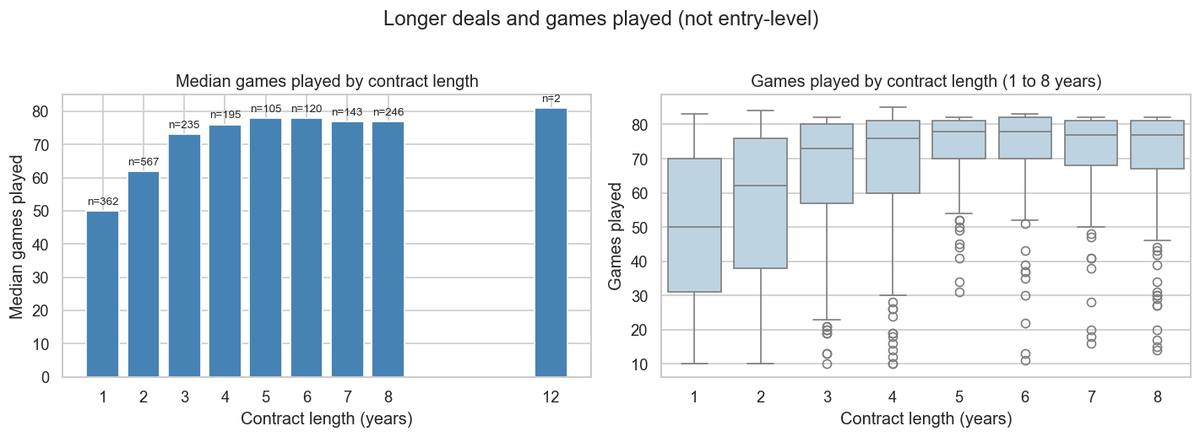

In [11]:
gp = (
    non_elc.groupby("ContractLength", as_index=False)
    .agg(n=("GP", "size"), median_gp=("GP", "median"))
    .sort_values("ContractLength")
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = gp.ContractLength.astype(int)
bars = axes[0].bar(x, gp.median_gp, color=COLOR_MARKET, edgecolor="white")
label_n(axes[0], bars, gp.n, dy=1.2)
axes[0].set(xlabel=lab("ContractLength"), ylabel=f"Median {lab('GP').lower()}",
            title="Median games played by contract length", xticks=x)
sns.boxplot(data=non_elc[non_elc.ContractLength.between(1, 8)],
            x="ContractLength", y="GP", color=COLOR_MARKET_LIGHT, ax=axes[1])
axes[1].set(xlabel=lab("ContractLength"), ylabel=lab("GP"),
            title="Games played by contract length (1 to 8 years)")
fig.suptitle("Longer deals and games played (not entry-level)", y=1.02)
plt.tight_layout(); plt.show()


### Takeaways

Those pay tiers also sit on very different terms. Among non entry-level skaters over these three years, one and two year deals are the most common by a clear margin while five and six year terms are among the thinnest groups, and median share of the salary cap rises steadily as term gets longer.

Games played do not follow the same staircase, and although the five to six year boxplot looks steadier than its neighbours, the group is small enough that the pattern is better read as clubs giving real term to players they already trust than as evidence that longer contracts produce healthier seasons.


## 4. Age and share of the salary cap

Who filled the league by age over these three seasons, how median pay sits by age, and how contract length mix looks among non entry-level players. Age is age in the season.


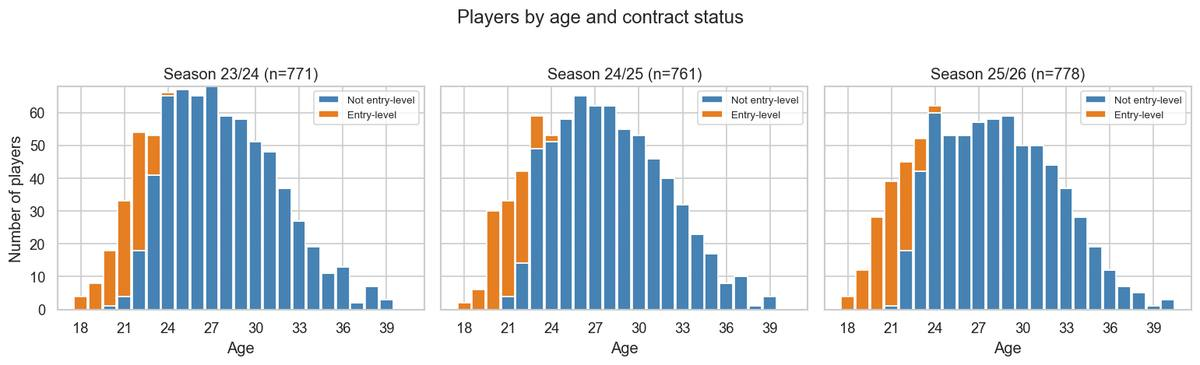

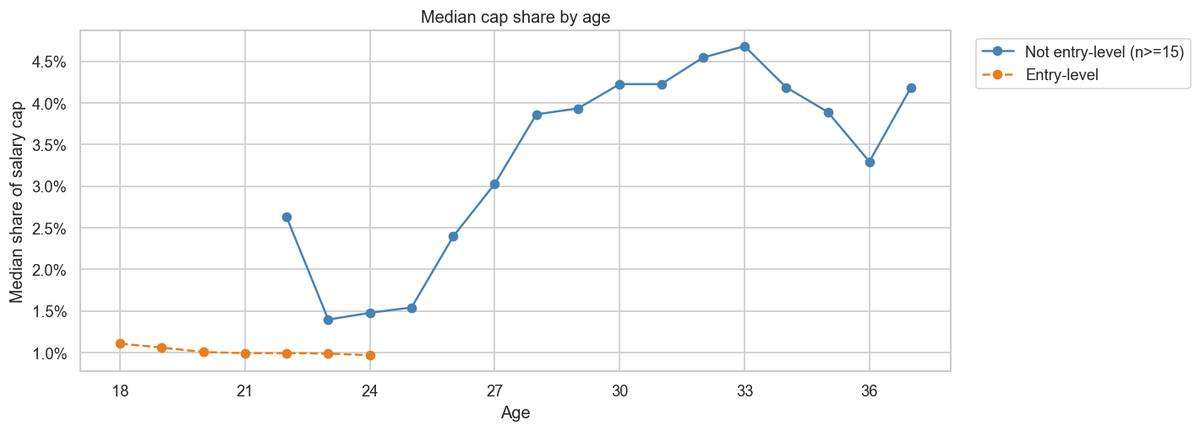

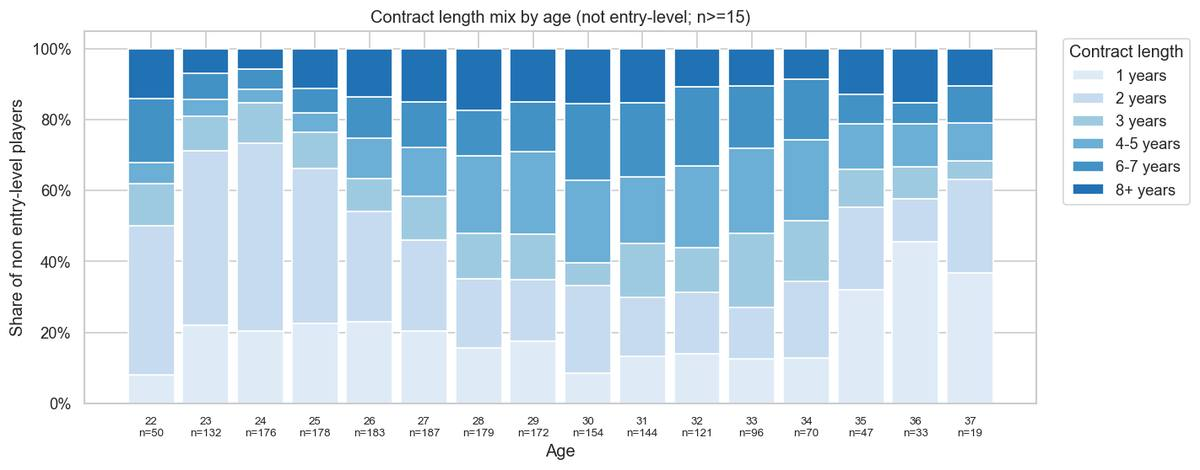

In [13]:
# 1) Age mix by season
ages = np.arange(int(df.Age.min()), int(df.Age.max()) + 1)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, s in zip(axes, SEASONS):
    sub = df[df.Season == s]
    non = sub.loc[sub.Is_ELC != 1, "Age"].value_counts().reindex(ages, fill_value=0)
    el = sub.loc[sub.Is_ELC == 1, "Age"].value_counts().reindex(ages, fill_value=0)
    ax.bar(ages, non, color=COLOR_NON_ELC, edgecolor="white", width=0.9, label="Not entry-level")
    ax.bar(ages, el, bottom=non, color=COLOR_ELC, edgecolor="white", width=0.9, label="Entry-level")
    ax.set(title=f"Season {season_label(s)} (n={len(sub)})", xlabel=lab("Age"))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("Number of players")
fig.suptitle("Players by age and contract status", y=1.02)
plt.tight_layout(); plt.show()

# 2) Median cap share by age
age_non = non_elc.groupby("Age", as_index=False).agg(n=("CapHit_pct", "size"), median_pct=("CapHit_pct", "median"))
age_elc = elc.groupby("Age", as_index=False).agg(n=("CapHit_pct", "size"), median_pct=("CapHit_pct", "median"))
plot_non = age_non[age_non.n >= 15]

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(plot_non.Age, plot_non.median_pct, "o-", color=COLOR_NON_ELC, label="Not entry-level (n>=15)")
ax.plot(age_elc.Age, age_elc.median_pct, "o--", color=COLOR_ELC, label="Entry-level")
ax.set(xlabel=lab("Age"), ylabel=f"Median {lab('CapHit_pct').lower()}", title="Median cap share by age")
ax.yaxis.set_major_formatter(PCT1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

# 3) Length mix by age
MIN_N = 15
fig, ax = plt.subplots(figsize=(12, 4.8))
plot_length_mix(ax, non_elc, min_n=MIN_N)
ax.set(xlabel=lab("Age"), ylabel="Share of non entry-level players",
       title=f"Contract length mix by age (not entry-level; n>={MIN_N})")
ax.legend(title="Contract length", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


### Takeaways

Behind those contracts, the age profile of the league shifted slightly over the window, with 25/26 looking a little older than 23/24 while entry-level players stay concentrated at the young end. Median pay among non entry-level players climbs into a band of roughly 30 to 34, and that band is thinner than the mid and late 20s, which reads as selection, since the players still holding regular NHL roles at that age tend to be the established and better paid ones.

The small bump near age 22 works the same way in reverse, because most 22 year olds are still on entry-level deals and the non entry-level slice at that age already includes some large second contracts, while ages 23 to 25 fill with cheaper bridges and pull the median back down. Longer deals and higher pay overlap through the early 30s before the mix swings back toward short terms at older ages.


## 5. Forwards vs defensemen: pay and contract length by age

Same in-season view as section 4, split by position among non entry-level players.


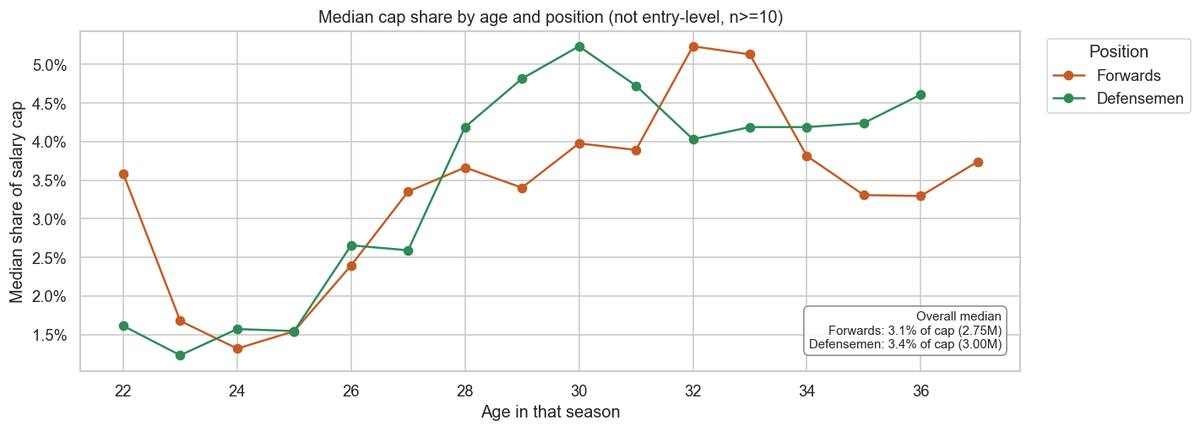

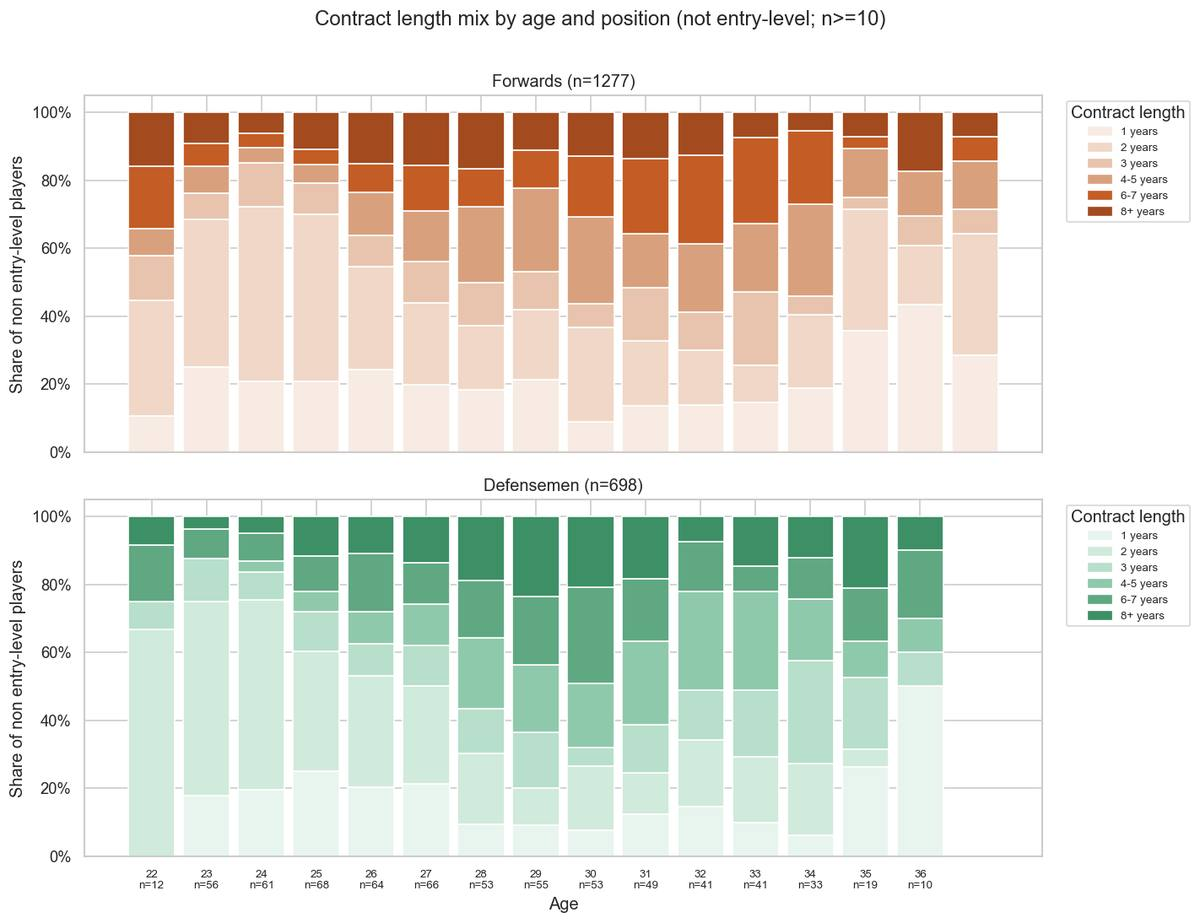

In [17]:
# Pay curve F vs D
age_fd = (
    non_elc.groupby(["FD", "Age"], as_index=False)
    .agg(n=("CapHit_pct", "size"), median_pct=("CapHit_pct", "median"))
)
age_fd = age_fd[age_fd.n >= 10]

fig, ax = plt.subplots(figsize=(12, 4.4))
for pos, color, name in [("F", COLOR_F, "Forwards"), ("D", COLOR_D, "Defensemen")]:
    g = age_fd[age_fd.FD == pos]
    ax.plot(g.Age, g.median_pct, "o-", color=color, label=name)
ax.set(xlabel="Age in that season", ylabel=f"Median {lab('CapHit_pct').lower()}",
       title="Median cap share by age and position (not entry-level, n>=10)")
ax.yaxis.set_major_formatter(PCT1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
med = non_elc.groupby("FD").agg(pct=("CapHit_pct", "median"), cap=("CapHit", "median"))
box = "Overall median\n" + "\n".join(
    f"{name}: {med.loc[p, 'pct']:.1%} of cap ({med.loc[p, 'cap']:.2f}M)"
    for p, name in [("F", "Forwards"), ("D", "Defensemen")]
)
ax.text(
    0.98, 0.06, box, transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#888", alpha=0.92),
)
plt.tight_layout(); plt.show()

# Length mix by age x position (stacked vertically for readability)
MIN_N = 10
fig, axes = plt.subplots(2, 1, figsize=(12, 9.0), sharex=True)
for ax, pos, title in zip(axes, ["F", "D"], ["Forwards", "Defensemen"]):
    sub = non_elc[non_elc.FD == pos]
    plot_length_mix(ax, sub, min_n=MIN_N, palette=LENGTH_COLORS_BY_POS[pos], xtick_fs=8, labeled=False)
    ax.set(xlabel="", ylabel="Share of non entry-level players", title=f"{title} (n={len(sub)})")
    ax.legend(
        [plt.Rectangle((0, 0), 1, 1, color=c) for c in LENGTH_COLORS_BY_POS[pos]],
        [f"{g} years" for g in LENGTH_GROUP_ORDER],
        title="Contract length", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
    )
axes[-1].set_xlabel(lab("Age"))
fig.suptitle(f"Contract length mix by age and position (not entry-level; n>={MIN_N})", y=1.01)
plt.tight_layout(); plt.show()


### Takeaways

Splitting the same three seasons by position, overall pay for non entry-level forwards and defensemen is close, but the age profile of that pay is not. Defensemen currently carry the higher medians through 28 to 31 and peak near age 30, while forwards take over around 32 and 33 and reach a similar ceiling there. Contract length follows a related pattern: young non entry-level defensemen sit heavily on two year deals, then hold long term contracts more often than forwards through the late twenties, whereas the young forward group already shows more multi-year deals.


## 6. Performance and pay


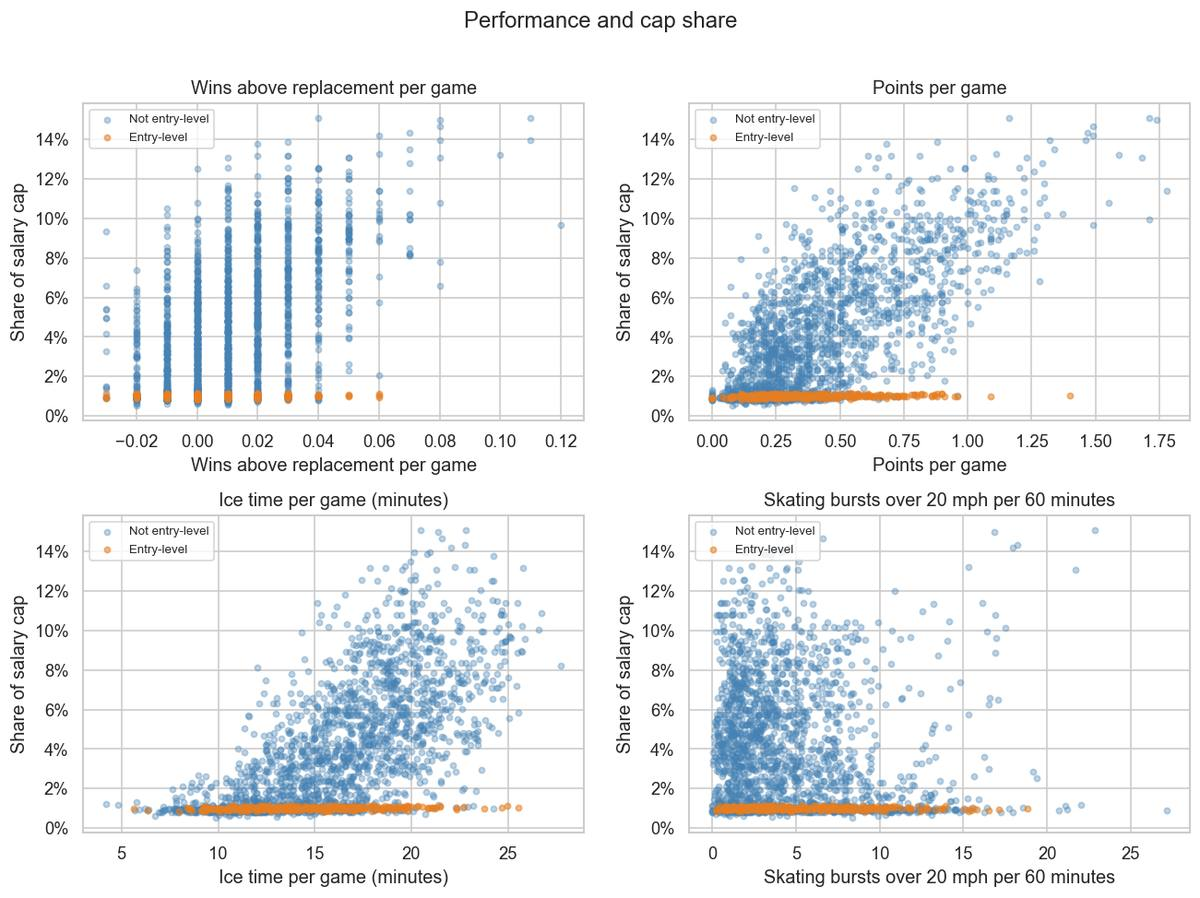

In [22]:
plot = df.assign(
    bursts_per_60=lambda d: d["nhl_edge_burstsOver20"] / (d["TOI/GP"] * d["GP"]).replace(0, np.nan) * 60
)
fig, axes = plt.subplots(2, 2, figsize=(11, 8.0))
for ax, col in zip(axes.ravel(), ["WAR_per_GP", "pointsPerGame", "TOI/GP", "bursts_per_60"]):
    for flag, name, color, alpha in [(0, "Not entry-level", COLOR_NON_ELC, 0.35), (1, "Entry-level", COLOR_ELC, 0.55)]:
        g = plot[plot.Is_ELC == flag]
        ax.scatter(g[col], g.CapHit_pct, s=14, alpha=alpha, color=color, label=name)
    ax.set(xlabel=lab(col), ylabel=lab("CapHit_pct"), title=lab(col))
    ax.yaxis.set_major_formatter(PCT0)
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Performance and cap share", y=1.01)
plt.tight_layout(); plt.show()


### Takeaways

Set against those contract shapes, same-season performance lines up with pay in the expected direction for non entry-level players, with higher WAR per game, points per game, ice time and bursts per 60 generally sitting alongside a larger share of the salary cap. Entry-level pay stays low because that money is capped by the CBA, yet those players often occupy the same performance range as the non entry-level cloud, so a small cap hit in this sample says more about contract status than about on-ice value.

That gap between what entry-level players produce and what they are allowed to earn is exactly what makes the first contract after entry-level worth a closer look.


## 7. End of entry-level deal: first contracts after ELC

Focus on players finishing ELC in this sample and the shape of their first non entry-level deal next season (length and cap hit). Charts cover the `23/24` to `24/25` and `24/25` to `25/26` windows among those who stayed in the GP >= 10 sample on a new deal.


stage   Final year  Rest
Season                  
23-24           50    57
24-25           45    62
25-26           54    67
Final-year share: {'23-24': 0.467, '24-25': 0.421, '25-26': 0.446}


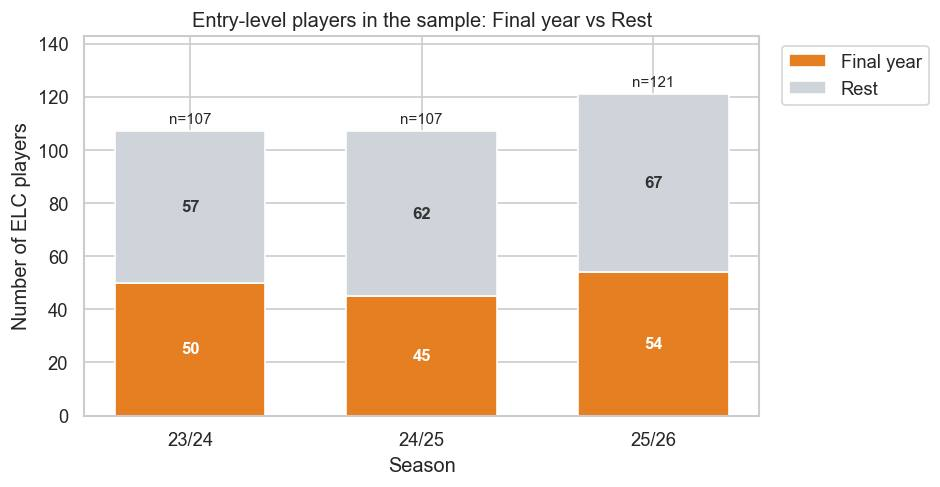

In [19]:
stock = (
    df[df.Is_ELC == 1]
    .assign(stage=lambda d: np.where(d.YearsRemaining == 0, "Final year", "Rest"))
    .groupby(["Season", "stage"]).size().unstack("stage")
    .reindex(index=SEASONS, columns=["Final year", "Rest"]).fillna(0).astype(int)
)

fig, ax = plt.subplots(figsize=(8, 4.2))
x, bottom = np.arange(len(SEASONS)), np.zeros(len(SEASONS))
for stage, color, tc in [("Final year", COLOR_ELC, "white"), ("Rest", COLOR_MUTED, "#333")]:
    vals = stock[stage].to_numpy()
    ax.bar(x, vals, bottom=bottom, color=color, edgecolor="white", width=0.65, label=stage)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v:
            ax.text(i, b + v / 2, str(v), ha="center", va="center", fontsize=10, color=tc, fontweight="bold")
    bottom += vals
for i, tot in enumerate(stock.sum(axis=1)):
    ax.text(i, tot + 2, f"n={tot}", ha="center", va="bottom", fontsize=9)
ax.set(xticks=x, xticklabels=[season_label(s) for s in SEASONS], xlabel="Season",
       ylabel="Number of ELC players", title="Entry-level players in the sample: Final year vs Rest",
       ylim=(0, stock.sum(axis=1).max() * 1.18))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
print(stock)
print("Final-year share:", (stock["Final year"] / stock.sum(axis=1)).round(3).to_dict())


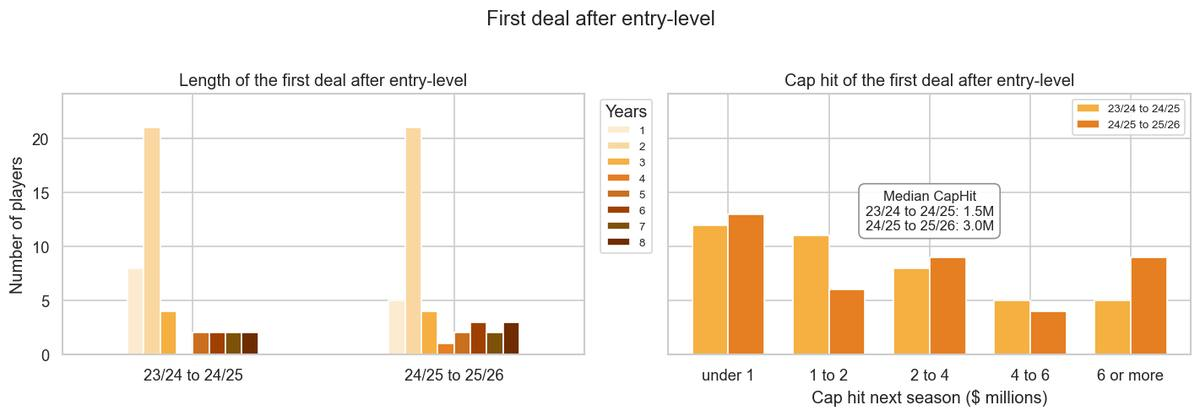

In [ ]:
def elc_first_deals(season_from, season_to):
    base = df[(df.Season == season_from) & (df.Is_ELC == 1) & (df.YearsRemaining == 0)][["playerId"]]
    nxt = df.loc[df.Season == season_to, ["playerId", "Is_ELC", "CapHit", "ContractLength"]].rename(
        columns={"Is_ELC": "Is_ELC_next", "CapHit": "CapHit_next", "ContractLength": "Length_next"}
    )
    out = base.merge(nxt, on="playerId", how="left")
    out = out[out.Is_ELC_next.eq(0)].copy()
    out["Length_next"] = out["Length_next"].astype(int)
    out["CapHit_next"] = np.where(out["CapHit_next"] > 100, out["CapHit_next"] / 1e6, out["CapHit_next"])
    out["window"] = season_window_label(season_from, season_to)
    return out


windows = [("23-24", "24-25"), ("24-25", "25-26")]
win_labels = [season_window_label(a, b) for a, b in windows]
ok = pd.concat([elc_first_deals(*w) for w in windows], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), sharey=True)

ELC_ORANGE_LENGTH = [
    "#fdebd0", "#fad7a0", "#f5b041", "#e67e22", "#ca6f1e", "#a04000", "#7e5109", "#6e2c00",
]
ELC_WINDOW = ["#f5b041", COLOR_ELC]  # light orange, Final-year orange

length_ct = pd.crosstab(ok.window, ok.Length_next).reindex(index=win_labels).fillna(0).astype(int)
length_ct.plot(
    kind="bar", ax=axes[0], edgecolor="white",
    color=length_colors_for(length_ct.columns, palette=ELC_ORANGE_LENGTH), rot=0,
)
axes[0].set(xlabel="", ylabel="Number of players", title="Length of the first deal after entry-level")
axes[0].legend(title="Years", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

cap_labels = ["under 1", "1 to 2", "2 to 4", "4 to 6", "6 or more"]
ok["CapHit_bin"] = pd.cut(ok.CapHit_next, bins=[0, 1, 2, 4, 6, 20], labels=cap_labels, right=False)
cap_ct = pd.crosstab(ok.CapHit_bin, ok.window).reindex(index=cap_labels, columns=win_labels).fillna(0).astype(int)
x = np.arange(len(cap_labels))
for j, (col, color) in enumerate(zip(cap_ct.columns, ELC_WINDOW)):
    axes[1].bar(x + (j - 0.5) * 0.36, cap_ct[col], 0.36, label=col, color=color, edgecolor="white")
axes[1].set(xticks=x, xticklabels=cap_labels, xlabel=lab("CapHit_next"),
            title="Cap hit of the first deal after entry-level")
axes[1].legend(fontsize=8)

meds = ok.groupby("window", sort=False).CapHit_next.median()
med_txt = "Median CapHit\n" + "\n".join(f"{w}: {meds[w]:.1f}M" for w in win_labels if w in meds.index)
axes[1].text(
    0.5, 0.55, med_txt, transform=axes[1].transAxes, ha="center", va="center", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#888", alpha=0.92),
)

ymax = max(length_ct.to_numpy().max(initial=0), cap_ct.to_numpy().max(initial=0), 1) * 1.15
axes[0].set_ylim(0, ymax); axes[1].set_ylim(0, ymax)
fig.suptitle("First deal after entry-level", y=1.02)
plt.tight_layout(); plt.show()


### Takeaways

For the players who finished an entry-level contract and stayed in this sample on a new deal, that first contract is usually a modest step rather than a long commitment, with about half of them running two years and a median cap hit of about 1.5M in the 23/24 to 24/25 window and about 3.0M in 24/25 to 25/26. Both paths sit on the same chart, where Seider at about 8.55M over seven years and Hughes at about 9.0M over seven years appear alongside bridges such as LaCombe at about 0.92M over two years.

Because this view follows only the players who remained in the 10-game sample, it describes the shape of those first deals rather than the fate of every entry-level graduate. With pay, term and performance all on the table, the last step is to see which measurable signals travel with cap share most closely.


## 8. What travels with pay

Simple ranking of numeric signals versus share of the salary cap in this sample.


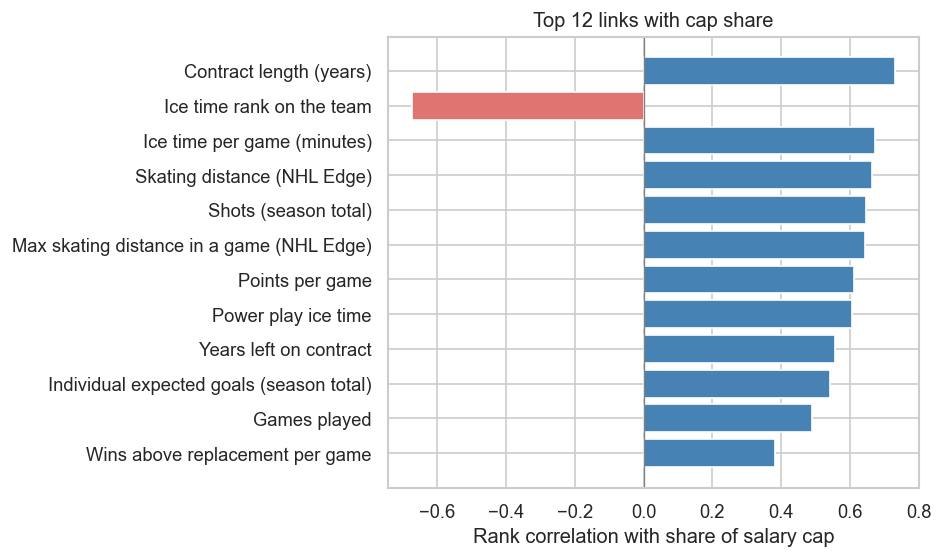

In [24]:
num = [
    "Season_id", "Age", "heightInInches", "weightInPounds", "GP", "TOI/GP", "Depth_TOI_rank",
    "PP TOI", "PK TOI", "Is_ELC", "ContractLength", "YearsRemaining",
    "WAR_per_GP", "EVO WAR", "EVD WAR", "PP WAR", "PK WAR", "pointsPerGame", "ixG", "shots",
    "xGF%", "OZ Start%", "xG_diff", "Team_pointPct", "Team_GF_pct", "Team_PP%", "Team_PK%",
    "nhl_edge_skatingSpeedMax_mph", "nhl_edge_burstsOver20", "nhl_edge_topShotSpeed_mph",
    "nhl_edge_totalDistanceSkated_mph", "nhl_edge_distanceMaxGame_mph",
    "nhl_edge_zoneTime_offensiveZonePctg",
]
top = (
    df[num + ["CapHit_pct"]].corr(method="spearman")["CapHit_pct"]
    .drop("CapHit_pct").sort_values(key=lambda s: s.abs(), ascending=False).head(12)
)
vals = top.values[::-1]
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh([lab(i) for i in top.index[::-1]], vals,
        color=[COLOR_POS if v >= 0 else COLOR_NEG for v in vals], edgecolor="white")
ax.set(xlabel=f"Rank correlation with {lab('CapHit_pct').lower()}",
       title="Top 12 links with cap share")
ax.axvline(0, color="gray", lw=0.8)
plt.tight_layout(); plt.show()


### Takeaways

Ranking the numeric signals against share of the salary cap points in one consistent direction, with contract length at the top and ice time, ice time rank on the team and games played close behind, followed by the offensive volume group of shots, points per game, power play time and expected goals. These are the signals that may matter most when estimating a player's cap hit for this season, and the modeling notebook picks up from there with residuals as reevaluation flags.
